# Notebook 5 — Deep Learning (Neural Network)

This notebook trains a **Multi-Layer Perceptron (MLP)** — a neural network — using scikit-learn, and compares it against the models from Notebook 3.

**Architecture:**
- Input layer: 30 features (V1–V28, Time, Amount)
- Hidden layer 1: 64 neurons, ReLU activation
- Hidden layer 2: 32 neurons, ReLU activation
- Hidden layer 3: 16 neurons, ReLU activation
- Output layer: 1 neuron, Sigmoid → probability of fraud

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

# MLPClassifier is scikit-learn's neural network
# It supports multiple hidden layers, ReLU activation, and early stopping
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    f1_score,
    roc_curve,
    precision_recall_curve
)

%matplotlib inline
print('Libraries loaded.')

Libraries loaded.


## 1. Load Processed Data

In [2]:
# Load the same training and test data used in Notebook 3
# train_resampled.csv: SMOTE-balanced training set (equal fraud/legitimate)
# test.csv: original class distribution (realistic evaluation)
train = pd.read_csv('../data/processed/train_resampled.csv')
test  = pd.read_csv('../data/processed/test.csv')

X_train = train.drop(columns=['Class'])
y_train = train['Class']

X_test = test.drop(columns=['Class'])
y_test = test['Class']

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Input features: {X_train.shape[1]}')

Train: (454902, 30) | Test: (56962, 30)
Input features: 30


## 2. Build & Train the Neural Network

**Key hyperparameters:**
- `hidden_layer_sizes=(64, 32, 16)`: three hidden layers with 64, 32, and 16 neurons
- `activation='relu'`: ReLU activation — fast and avoids vanishing gradients
- `solver='adam'`: adaptive learning rate optimizer (standard choice)
- `early_stopping=True`: stop training if validation score stops improving (prevents overfitting)
- `max_iter=50`: maximum number of passes through the training data

In [3]:
# Define the neural network
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),  # 3 hidden layers: 64 → 32 → 16 neurons
    activation='relu',                # ReLU activation for hidden layers
    solver='adam',                    # Adam optimizer (adaptive learning rate)
    max_iter=50,                      # Maximum training epochs
    early_stopping=True,              # Stop if validation score doesn't improve
    validation_fraction=0.1,          # Use 10% of training data for validation
    n_iter_no_change=5,               # Stop after 5 epochs without improvement
    random_state=42,
    verbose=True                      # Print progress each epoch
)

print('Training neural network...')
mlp.fit(X_train, y_train)
print(f'\nTraining stopped at epoch: {mlp.n_iter_}')

Training neural network...
Iteration 1, loss = 0.03486538
Validation score: 0.998637
Iteration 2, loss = 0.00495065
Validation score: 0.999450
Iteration 3, loss = 0.00331410
Validation score: 0.999341
Iteration 4, loss = 0.00253556
Validation score: 0.999165
Iteration 5, loss = 0.00237977
Validation score: 0.998923
Iteration 6, loss = 0.00197696
Validation score: 0.999648
Iteration 7, loss = 0.00163446
Validation score: 0.998747
Iteration 8, loss = 0.00176204
Validation score: 0.999055
Iteration 9, loss = 0.00150791
Validation score: 0.999758
Iteration 10, loss = 0.00127592
Validation score: 0.999824
Iteration 11, loss = 0.00137702
Validation score: 0.999560
Iteration 12, loss = 0.00128029
Validation score: 0.999714
Iteration 13, loss = 0.00103850
Validation score: 0.999626
Iteration 14, loss = 0.00089373
Validation score: 0.999758
Iteration 15, loss = 0.00109464
Validation score: 0.999626
Validation score did not improve more than tol=0.000100 for 5 consecutive epochs. Stopping.

Trai

## 3. Training History

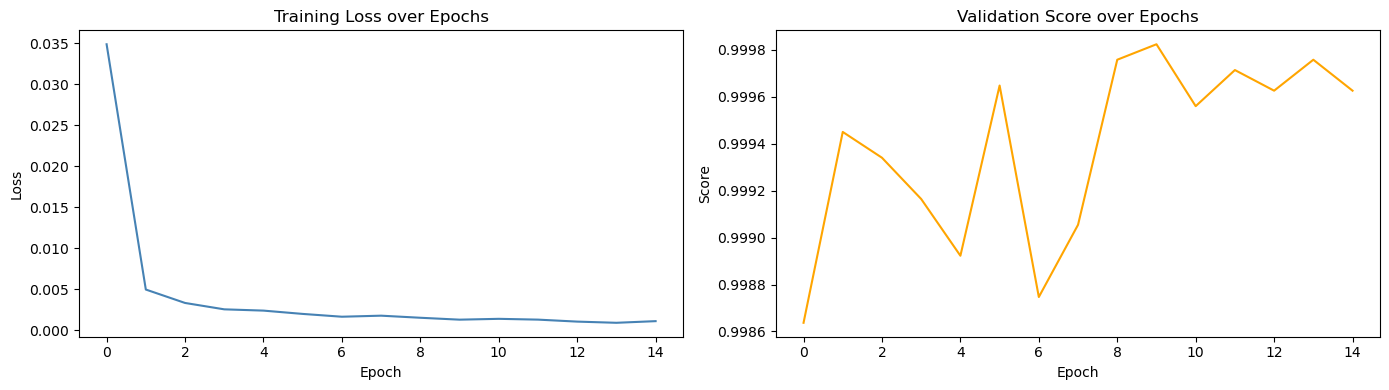

In [4]:
# Plot the loss curve over training epochs
# loss_curve_: training loss at each epoch
# validation_scores_: validation score at each epoch (used for early stopping)
# A good model shows both curves decreasing and converging

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: Training loss
axes[0].plot(mlp.loss_curve_, color='steelblue')
axes[0].set_title('Training Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

# Right: Validation score (higher is better)
axes[1].plot(mlp.validation_scores_, color='orange')
axes[1].set_title('Validation Score over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('../reports/nn_training_history.png', dpi=150)
plt.show()

## 4. Evaluate on Test Set

In [5]:
# Hard predictions (0 or 1)
y_pred = mlp.predict(X_test)

# Probability predictions — [:, 1] = probability of fraud
y_proba = mlp.predict_proba(X_test)[:, 1]

# Calculate key metrics
auc = roc_auc_score(y_test, y_proba)
ap  = average_precision_score(y_test, y_proba)
f1  = f1_score(y_test, y_pred)

print(f'AUC-ROC:        {auc:.4f}')
print(f'Avg Precision:  {ap:.4f}')
print(f'F1 (Fraud):     {f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

AUC-ROC:        0.9738
Avg Precision:  0.8428
F1 (Fraud):     0.7826

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.74      0.83      0.78        98

    accuracy                           1.00     56962
   macro avg       0.87      0.91      0.89     56962
weighted avg       1.00      1.00      1.00     56962



## 5. Compare with Previous Models

In [6]:
# Load the three models trained in Notebook 3
model_names   = ['logistic_regression', 'random_forest', 'xgboost']
display_names = ['Logistic Regression', 'Random Forest', 'XGBoost']

sklearn_models = {}
for mn in model_names:
    with open(f'../reports/models/{mn}.pkl', 'rb') as f:
        sklearn_models[mn] = pickle.load(f)

# Build comparison table
rows = []
for mn, dn in zip(model_names, display_names):
    yp    = sklearn_models[mn].predict(X_test)
    yprob = sklearn_models[mn].predict_proba(X_test)[:, 1]
    rows.append({
        'Model':         dn,
        'AUC-ROC':       roc_auc_score(y_test, yprob),
        'Avg Precision': average_precision_score(y_test, yprob),
        'F1 (Fraud)':    f1_score(y_test, yp)
    })

# Add neural network
rows.append({
    'Model':         'Neural Network (MLP)',
    'AUC-ROC':       auc,
    'Avg Precision': ap,
    'F1 (Fraud)':    f1
})

summary = pd.DataFrame(rows).set_index('Model')
print(summary.to_string())
summary.to_csv('../reports/model_comparison_with_nn.csv')

                       AUC-ROC  Avg Precision  F1 (Fraud)
Model                                                    
Logistic Regression   0.969848       0.724861    0.109356
Random Forest         0.984096       0.873440    0.822917
XGBoost               0.979159       0.877425    0.801843
Neural Network (MLP)  0.973791       0.842818    0.782609


## 6. ROC & Precision-Recall Curves (All Models)

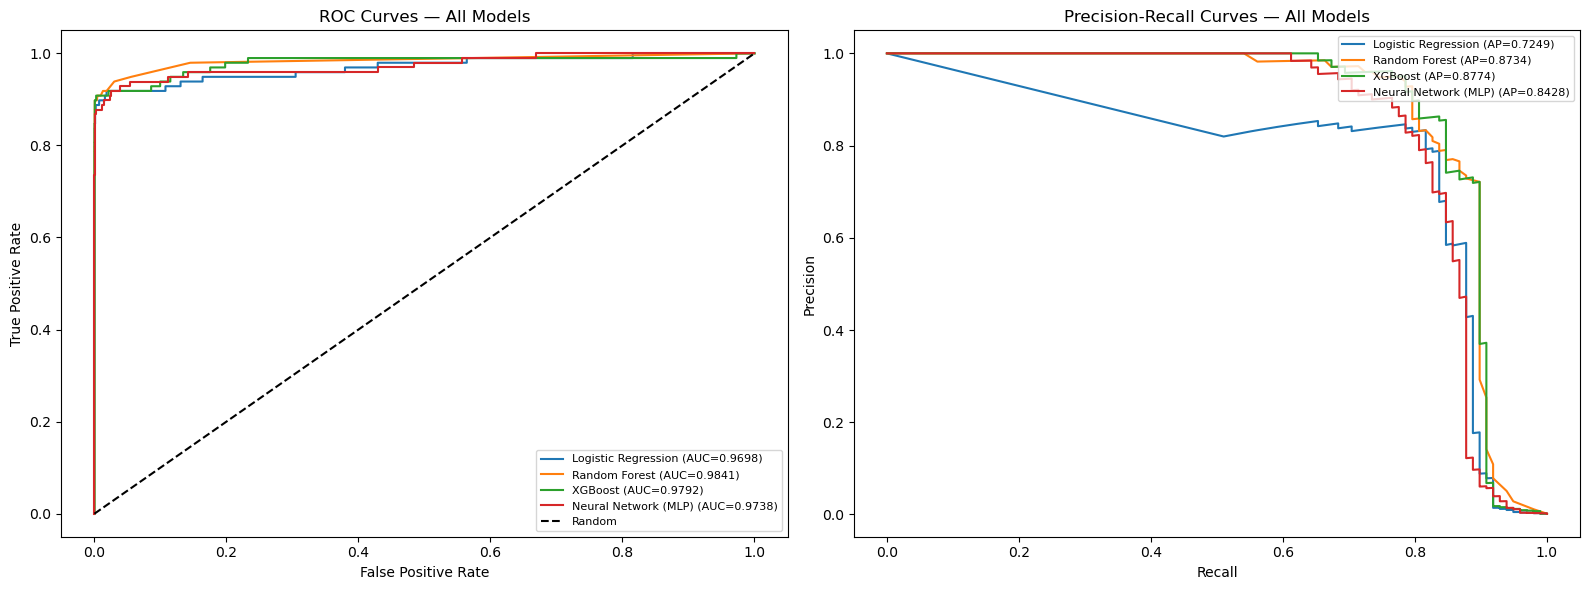

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Collect all probability predictions
all_probas = {}
for mn, dn in zip(model_names, display_names):
    all_probas[dn] = sklearn_models[mn].predict_proba(X_test)[:, 1]
all_probas['Neural Network (MLP)'] = y_proba

# ROC Curves
for name, proba in all_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    score = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={score:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models')
axes[0].legend(loc='lower right', fontsize=8)

# Precision-Recall Curves
for name, proba in all_probas.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap_score = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, label=f'{name} (AP={ap_score:.4f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — All Models')
axes[1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('../reports/all_models_curves.png', dpi=150)
plt.show()

## 7. Save the Neural Network

In [8]:
os.makedirs('../reports/models', exist_ok=True)
with open('../reports/models/neural_network.pkl', 'wb') as f:
    pickle.dump(mlp, f)
print('Neural network saved to ../reports/models/neural_network.pkl')

Neural network saved to ../reports/models/neural_network.pkl
